In [17]:
# 1. Cargamos nuestro Checkpoint (por si has reiniciado el ordenador)
import pandas as pd


df_ml = pd.read_csv('../data/dataset_smart_campus_master.csv')
df_ml['Timestamp'] = pd.to_datetime(df_ml['Timestamp'])

# 2. EXTRAER LA HORA
df_ml['Hora_del_Dia'] = df_ml['Timestamp'].dt.hour

# 3. ONE-HOT ENCODING (Convertir texto a 0s y 1s)
# drop_first=True evita la trampa de las variables ficticias (Multicolinealidad)
columnas_categoricas = ['Dia_Semana', 'tipus_dia']
df_ml = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

# 4. PREPARAR EL DATASET FINAL (X e y)
# Eliminamos las columnas que el modelo no puede procesar (Texto o Fechas complejas)
# Guardamos el Timestamp aparte por si luego queremos hacer gráficas bonitas
fechas_para_graficar = df_ml['Timestamp'] 
df_ml = df_ml.drop(columns=['Timestamp'])
df_ml = df_ml.drop(columns=['Ocupacion_Simulada.1'])
# Eliminar fallos de sensor (Es físicamente imposible consumir menos de 10 kWh en todo el campus)
df_ml = df_ml[df_ml['Consumo_kWh'] > 10]

# Convertimos todos los booleanos (True/False) que genera get_dummies a números (1/0)
df_ml = df_ml.astype(float)

print("¡Feature Engineering completado! Datos listos para Machine Learning.")
df_ml.head()

¡Feature Engineering completado! Datos listos para Machine Learning.


,Temperatura,Lluvia,Ocupacio_Percent,Ocupacion_Simulada,Consumo_kWh,Hora_del_Dia,Dia_Semana_Jueves,Dia_Semana_Lunes,Dia_Semana_Martes,Dia_Semana_Miércoles,...,Dia_Semana_Viernes,tipus_dia_Avaluacio,tipus_dia_Classe,tipus_dia_Dissabte,tipus_dia_Diumenge,tipus_dia_Festiu,tipus_dia_La Benvinguda,tipus_dia_Lectiu,tipus_dia_No lectiu,tipus_dia_Vacances
0,8.0,0.0,0.0,0.0,96.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7.7,0.0,0.0,0.0,96.0,2.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7.5,0.0,0.0,0.0,97.0,3.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7.7,0.0,0.0,0.0,96.0,4.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,7.6,0.0,0.0,0.0,95.0,5.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
# 1. EL RECUENTO GENERAL: ¿En qué columnas faltan datos?
print("--- RECUENTO DE NULOS POR COLUMNA ---")
nulos_por_columna = df_ml.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0]) # Solo muestra las que tienen errores

# 2. LA INSPECCIÓN VISUAL: Ver las filas exactas que están rotas
filas_con_nulos = df_ml[df_ml.isnull().any(axis=1)]

print(f"\n--- FILAS AFECTADAS ---")
print(f"Hay un total de {len(filas_con_nulos)} filas con al menos un dato faltante.")
print("Aquí tienes una muestra de esas horas conflictivas:")

# Mostramos las primeras 10 filas que tienen algún NaN
filas_con_nulos.head(10)

--- RECUENTO DE NULOS POR COLUMNA ---
Series([], dtype: int64)

--- FILAS AFECTADAS ---
Hay un total de 0 filas con al menos un dato faltante.
Aquí tienes una muestra de esas horas conflictivas:


,Temperatura,Lluvia,Ocupacio_Percent,Ocupacion_Simulada,Consumo_kWh,Hora_del_Dia,Dia_Semana_Jueves,Dia_Semana_Lunes,Dia_Semana_Martes,Dia_Semana_Miércoles,...,Dia_Semana_Viernes,tipus_dia_Avaluacio,tipus_dia_Classe,tipus_dia_Dissabte,tipus_dia_Diumenge,tipus_dia_Festiu,tipus_dia_La Benvinguda,tipus_dia_Lectiu,tipus_dia_No lectiu,tipus_dia_Vacances


Training

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# --- 1. EL ESCUDO ANTI-NaN ---
# Mostramos cuántos errores había (para ponerlo en la memoria de tu TFG)
nulos_antes = df_ml.isna().sum().sum()
print(f"Detectados {nulos_antes} valores vacíos (NaN) en el dataset.")

# Eliminamos cualquier fila que tenga al menos una celda vacía
df_ml = df_ml.dropna()
print("¡Limpieza completada! Valores nulos eliminados.\n")

# --- 2. SEPARACIÓN DE DATOS ---
X = df_ml.drop(columns=['Consumo_kWh'])
y = df_ml['Consumo_kWh']

# Dividimos: 80% para entrenar, 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO ---
print("Entrenando la Inteligencia Artificial... 🧠")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# --- 4. PREDICCIÓN Y EVALUACIÓN ---
predicciones = modelo_rf.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"--- 📊 Resultados del Modelo ---")
print(f"Error Medio Absoluto (MAE): {mae:.2f} kWh")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} kWh")
print(f"Precisión (R2 Score): {r2:.4f}")

Detectados 0 valores vacíos (NaN) en el dataset.
¡Limpieza completada! Valores nulos eliminados.

Entrenando la Inteligencia Artificial... 🧠
--- 📊 Resultados del Modelo ---
Error Medio Absoluto (MAE): 11.94 kWh
Raíz del Error Cuadrático Medio (RMSE): 19.65 kWh
Precisión (R2 Score): 0.9673


🏟️ ¡Comienza el Torneo de Modelos!

Entrenando Regresión Lineal...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando XGBoost...

🏆 --- RANKING DEFINITIVO DEL TFG --- 🏆
           Modelo  MAE (Error)  Precisión (R2)
    Random Forest    11.935671        0.967343
          XGBoost    13.557300        0.963536
Árbol de Decisión    14.335423        0.947979
Gradient Boosting    18.200652        0.936751
 Regresión Lineal    33.900428        0.815329


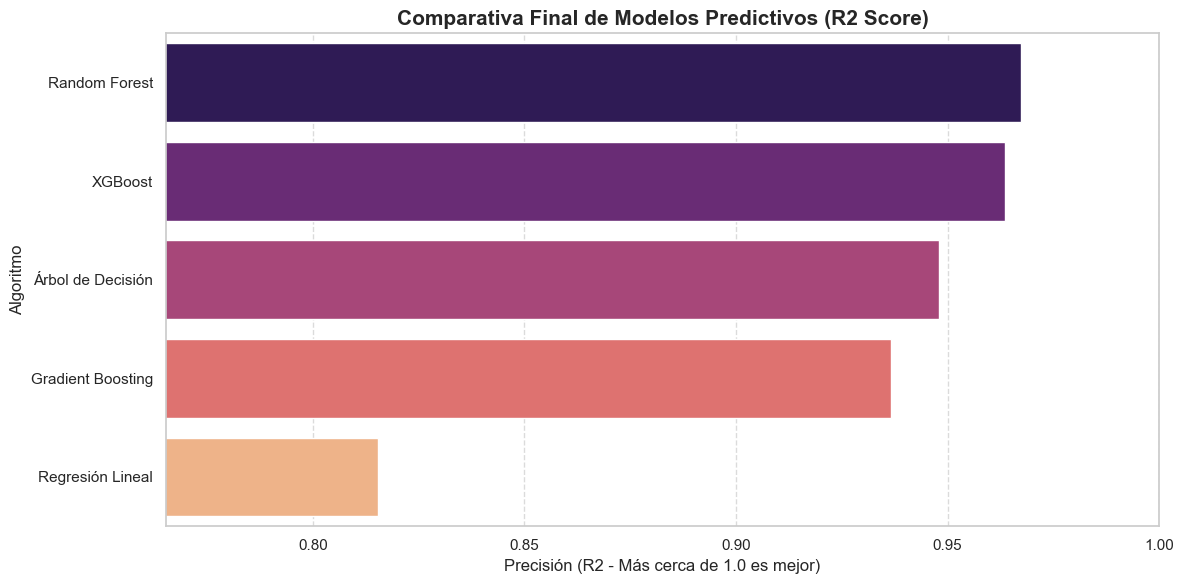

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DEFINIMOS LOS COMPETIDORES
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5,
        random_state=42,
        objective='reg:squarederror') # Parámetro para evitar advertencias en consola
}

resultados = []

print("🏟️ ¡Comienza el Torneo de Modelos!\n")

# 2. ENTRENAMOS Y EVALUAMOS CADA MODELO AUTOMÁTICAMENTE
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    predicciones = modelo.predict(X_test)
    
    # Evaluar
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    # Guardar resultados
    resultados.append({"Modelo": nombre, "MAE (Error)": mae, "Precisión (R2)": r2})

# 4. CREAMOS EL RANKING FINAL
df_resultados = pd.DataFrame(resultados).sort_values(by="Precisión (R2)", ascending=False)

print("\n🏆 --- RANKING DEFINITIVO DEL TFG --- 🏆")
print(df_resultados.to_string(index=False))

# 5. VISUALIZAMOS AL CAMPEÓN
plt.figure(figsize=(12, 6))
# Usamos la paleta 'magma' para darle un toque más técnico a la presentación
sns.barplot(x="Precisión (R2)", y="Modelo", data=df_resultados, palette="magma")
plt.title("Comparativa Final de Modelos Predictivos (R2 Score)", fontsize=15, fontweight='bold')
plt.xlim(df_resultados["Precisión (R2)"].min() - 0.05, 1) # Ajustamos el zoom para ver bien las diferencias
plt.xlabel("Precisión (R2 - Más cerca de 1.0 es mejor)", fontsize=12)
plt.ylabel("Algoritmo", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

print("Iniciando la búsqueda de los hiperparámetros perfectos para XGBoost...")
print("(Esto puede tardar uno o dos minutos, la IA está entrenando cientos de modelos ⏳)\n")

# 1. Definimos el espacio de búsqueda (las opciones que la IA puede probar)
parametros_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0], # Porcentaje de datos que usa cada árbol (evita overfitting)
}

# 2. Configuramos el "Buscador"
# RandomizedSearchCV prueba combinaciones al azar (n_iter=20 probará 20 combinaciones distintas)
xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
buscador = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=parametros_xgb,
    n_iter=20,          
    cv=3,                # Validación cruzada (se asegura de que no sea suerte)
    scoring='r2',        # Queremos maximizar la precisión (R2)
    random_state=42,
    n_jobs=-1            # Usa todos los núcleos de tu procesador para ir más rápido
)

# 3. Lanzamos la búsqueda
buscador.fit(X_train, y_train)

# 4. Resultados
xgb_optimizado = buscador.best_estimator_
predicciones_opt = xgb_optimizado.predict(X_test)

mae_opt = mean_absolute_error(y_test, predicciones_opt)
r2_opt = r2_score(y_test, predicciones_opt)

print("🏆 --- RESULTADOS DE LA OPTIMIZACIÓN --- 🏆")
print(f"Mejor configuración encontrada:")
print(buscador.best_params_)
print("\nNuevas Métricas del XGBoost Optimizado:")
print(f"Precisión (R2): {r2_opt:.6f} (Baseline era 0.960961)")
print(f"MAE (Error):    {mae_opt:.2f} kWh (Baseline era 13.01 kWh)")

Iniciando la búsqueda de los hiperparámetros perfectos para XGBoost...
(Esto puede tardar uno o dos minutos, la IA está entrenando cientos de modelos ⏳)

🏆 --- RESULTADOS DE LA OPTIMIZACIÓN --- 🏆
Mejor configuración encontrada:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}

Nuevas Métricas del XGBoost Optimizado:
Precisión (R2): 0.969568 (Baseline era 0.960961)
MAE (Error):    11.80 kWh (Baseline era 13.01 kWh)


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("🌳 Iniciando la optimización del Random Forest para el combate final...")
print("(Buscando la configuración perfecta... ⏳)\n")

# 1. Definimos el espacio de búsqueda para Random Forest
parametros_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 30, None],  # None significa que crecen hasta el final
    'min_samples_split': [2, 5, 10],      # Muestras mínimas para dividir un nodo
    'min_samples_leaf': [1, 2, 4],        # Muestras mínimas que deben quedar al final de una rama
    'max_features': ['sqrt', 'log2', 1.0] # Cuántas variables mira cada árbol (1.0 = todas)
}

# 2. Configuramos el Buscador
rf_base = RandomForestRegressor(random_state=42)
buscador_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=parametros_rf,
    n_iter=20,           # Probará 20 combinaciones distintas
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1            # Usa todos los núcleos para acelerar
)

# 3. Lanzamos la búsqueda
buscador_rf.fit(X_train, y_train)

# 4. Resultados Finales
rf_optimizado = buscador_rf.best_estimator_
predicciones_rf_opt = rf_optimizado.predict(X_test)

mae_rf_opt = mean_absolute_error(y_test, predicciones_rf_opt)
r2_rf_opt = r2_score(y_test, predicciones_rf_opt)

print("🏆 --- RESULTADOS DE LA OPTIMIZACIÓN DEL RANDOM FOREST --- 🏆")
print(f"Mejor configuración encontrada:")
print(buscador_rf.best_params_)
print("\nNuevas Métricas del Random Forest Optimizado:")
print(f"Precisión (R2): {r2_rf_opt:.6f} (Su baseline era 0.963495)")
print(f"MAE (Error):    {mae_rf_opt:.2f} kWh (Su baseline era 11.56 kWh)")

🌳 Iniciando la optimización del Random Forest para el combate final...
(Buscando la configuración perfecta... ⏳)

🏆 --- RESULTADOS DE LA OPTIMIZACIÓN DEL RANDOM FOREST --- 🏆
Mejor configuración encontrada:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}

Nuevas Métricas del Random Forest Optimizado:
Precisión (R2): 0.968485 (Su baseline era 0.963495)
MAE (Error):    11.96 kWh (Su baseline era 11.56 kWh)


In [23]:
import joblib

# 1. Guardamos el modelo campeón (tu XGBoost optimizado)
# La extensión .pkl (Pickle) es el formato clásico para objetos de Python
joblib.dump(xgb_optimizado, 'modelo_xgboost_tfg.pkl')

# 2. CONSEJO PRO (Matrícula de Honor): Guardar la estructura de columnas
# Si el día de mañana le pasas al modelo la 'Lluvia' antes que la 'Temperatura', explotará.
# Guardar esta lista asegura que tu servidor web sepa en qué orden van los datos.
joblib.dump(list(X_train.columns), 'columnas_entrenamiento.pkl')

print("📦 ¡Modelo y estructura de datos guardados con éxito!")
print("Archivos generados: 'modelo_xgboost_tfg.pkl' y 'columnas_entrenamiento.pkl'")

📦 ¡Modelo y estructura de datos guardados con éxito!
Archivos generados: 'modelo_xgboost_tfg.pkl' y 'columnas_entrenamiento.pkl'


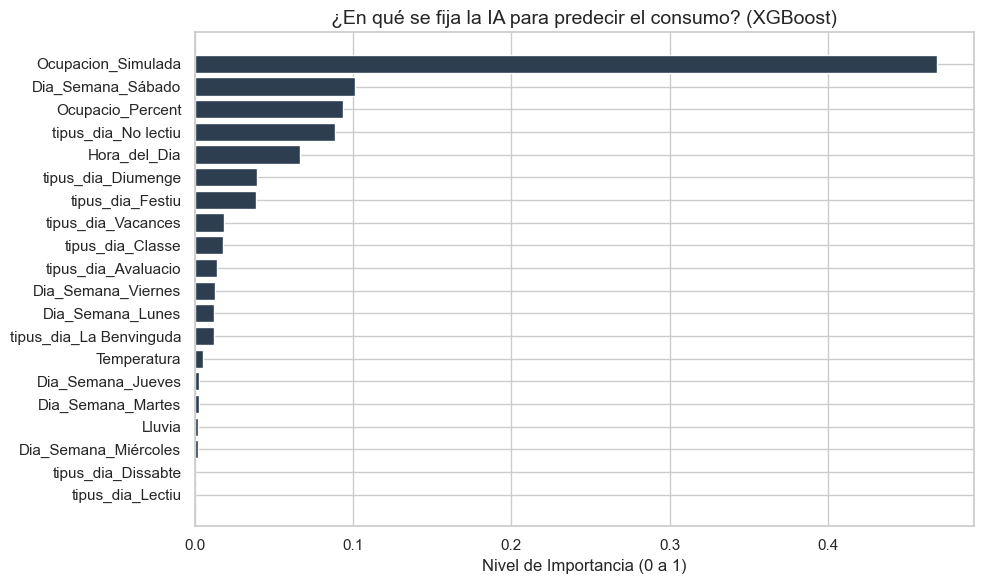

c:\Users\jordi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


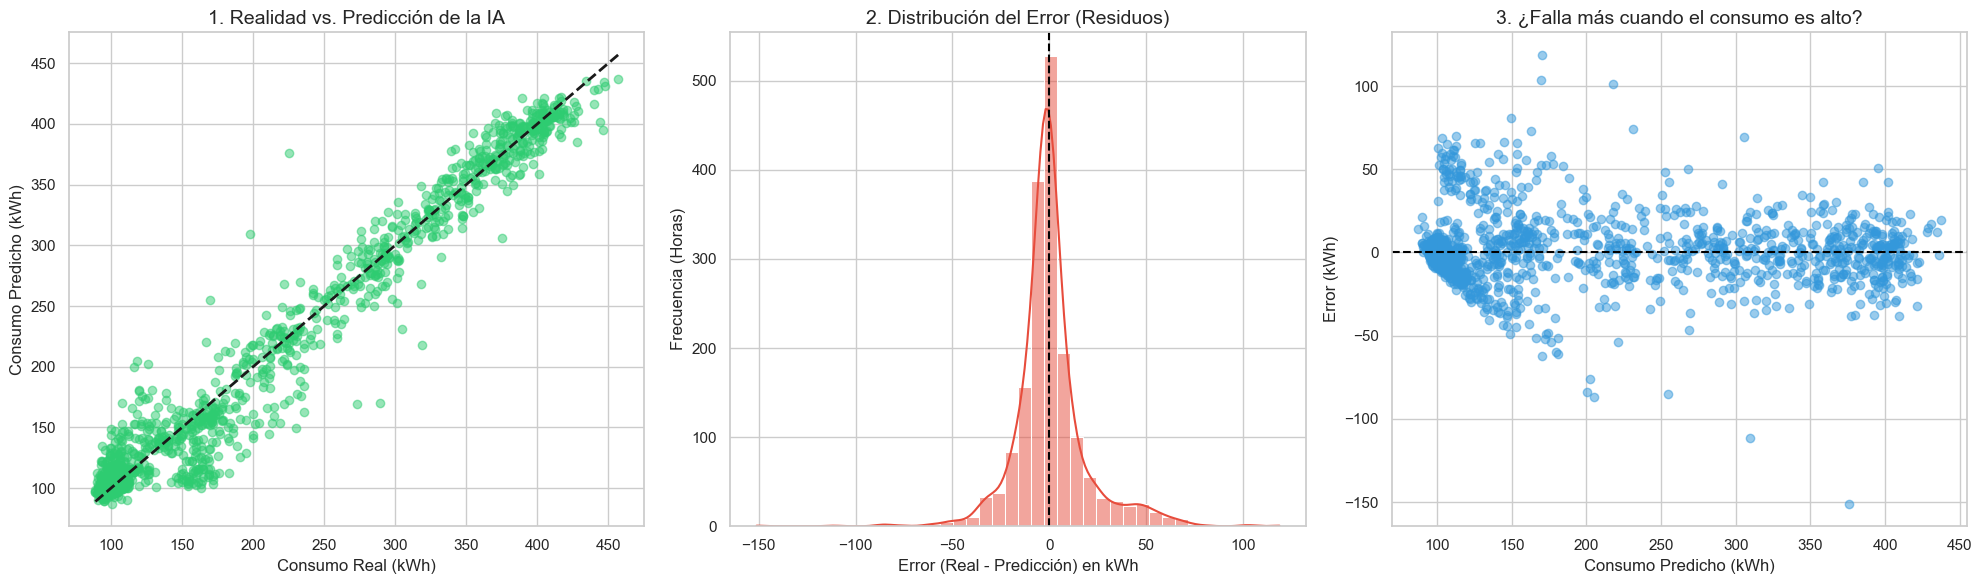

Calculando valores SHAP para el modelo optimizado (esto puede tardar unos segundos)...


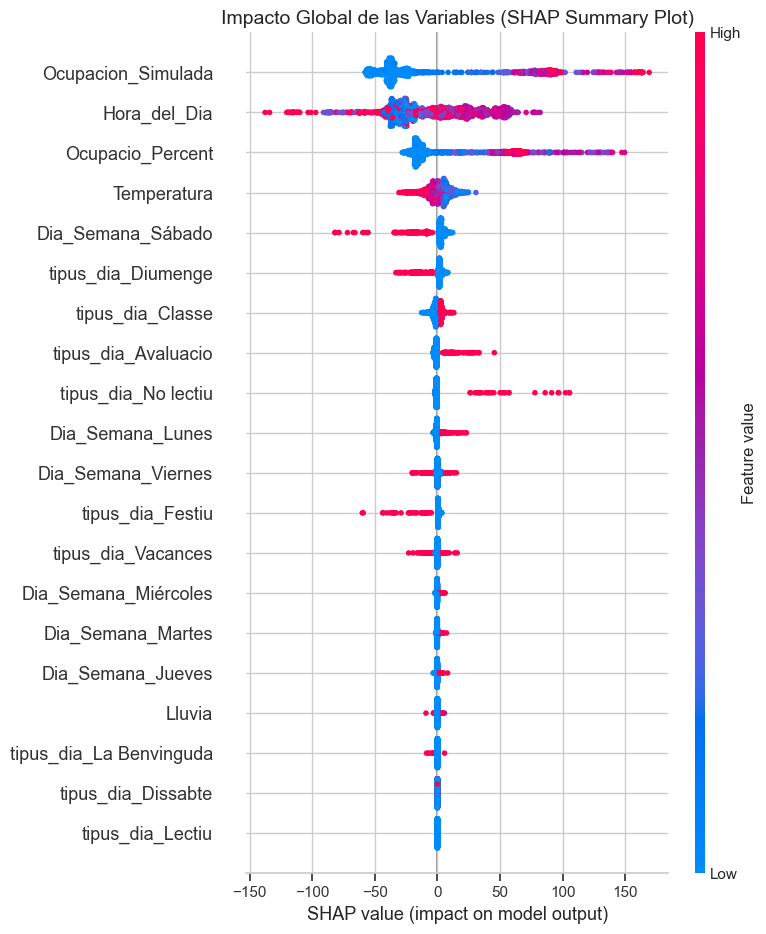

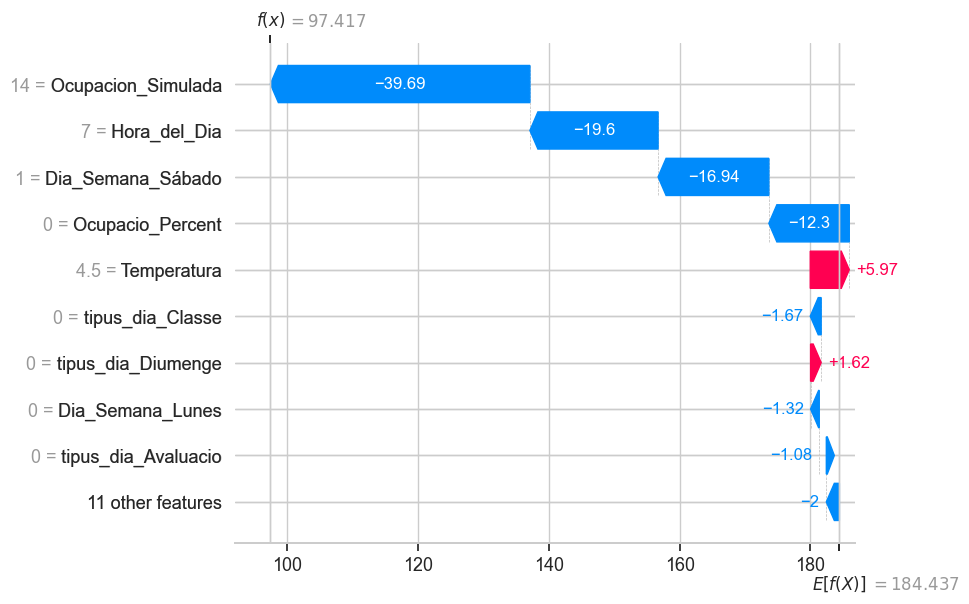

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- CONFIGURACIÓN DEL MODELO GANADOR ---
# Usamos el XGBoost optimizado que nos dio el mejor R2 (0.968)
modelo_final = xgb_optimizado
predicciones_finales = predicciones_opt

# Configuración visual general
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. ¿EN QUÉ SE FIJA LA IA? (Feature Importance Clásico)
# =====================================================================
plt.figure(figsize=(10, 6))
importancias = modelo_final.feature_importances_
columnas = X_train.columns

# Ordenamos las barras para que quede más visual en el TFG
indices_ordenados = importancias.argsort()
plt.barh(columnas[indices_ordenados], importancias[indices_ordenados], color='#2c3e50')
plt.title("¿En qué se fija la IA para predecir el consumo? (XGBoost)", fontsize=14)
plt.xlabel("Nivel de Importancia (0 a 1)")
plt.tight_layout()
plt.show()

# =====================================================================
# 2. ANÁLISIS DE RESIDUOS Y PRECISIÓN (3 Gráficos de Diagnóstico)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Predicción vs Realidad
axes[0].scatter(y_test, predicciones_finales, alpha=0.5, color='#2ecc71')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2) 
axes[0].set_title('1. Realidad vs. Predicción de la IA', fontsize=14)
axes[0].set_xlabel('Consumo Real (kWh)')
axes[0].set_ylabel('Consumo Predicho (kWh)')

# Gráfico 2: Distribución de los Errores (Histograma)
errores = y_test - predicciones_finales
sns.histplot(errores, bins=40, kde=True, ax=axes[1], color='#e74c3c')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('2. Distribución del Error (Residuos)', fontsize=14)
axes[1].set_xlabel('Error (Real - Predicción) en kWh')
axes[1].set_ylabel('Frecuencia (Horas)')

# Gráfico 3: Error vs Magnitud
axes[2].scatter(predicciones_finales, errores, alpha=0.5, color='#3498db')
axes[2].axhline(y=0, color='black', linestyle='--')
axes[2].set_title('3. ¿Falla más cuando el consumo es alto?', fontsize=14)
axes[2].set_xlabel('Consumo Predicho (kWh)')
axes[2].set_ylabel('Error (kWh)')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. EXPLICABILIDAD AVANZADA CON SHAP (Caja Blanca)
# =====================================================================
print("Calculando valores SHAP para el modelo optimizado (esto puede tardar unos segundos)...")
# Usamos TreeExplainer, que es 100% compatible con XGBoost y Random Forest
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_test)

# Gráfico Global: El "Summary Plot"
plt.figure(figsize=(10, 6))
plt.title("Impacto Global de las Variables (SHAP Summary Plot)", fontsize=14)
shap.summary_plot(shap_values, X_test)

# Gráfico Local: El "Waterfall Plot" (Explicando la primera hora del test)
plt.figure()
# shap_values[0] explica la primera predicción. Puedes probar con [10], [50], etc.
shap.plots.waterfall(shap_values[0])

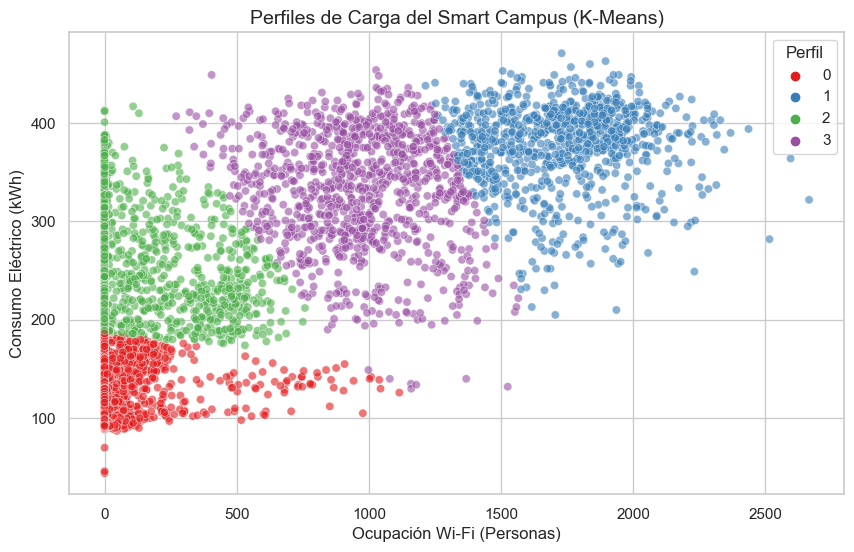

        Consumo_kWh  Ocupacion_Simulada
Perfil                                 
0        111.203865           20.446197
1        377.874864         1728.825898
2        255.768657          145.419569
3        331.636183          967.043738


In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos las columnas clave y ESCALAMOS (Normalizamos)
datos_cluster = df_ml[['Consumo_kWh', 'Ocupacion_Simulada']].copy()

scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos_cluster)

# 2. Aplicamos K-Means (Le pedimos que busque 4 perfiles de comportamiento)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
datos_cluster['Perfil'] = kmeans.fit_predict(datos_escalados)

# 3. Visualizamos los Clústeres
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Ocupacion_Simulada', 
    y='Consumo_kWh', 
    hue='Perfil', 
    palette='Set1', 
    data=datos_cluster, 
    alpha=0.6
)
plt.title("Perfiles de Carga del Smart Campus (K-Means)", fontsize=14)
plt.xlabel("Ocupación Wi-Fi (Personas)")
plt.ylabel("Consumo Eléctrico (kWh)")
plt.show()

# Veamos qué significa cada perfil matemáticamente
print(datos_cluster.groupby('Perfil').mean())

🚀 Iniciando Clustering por Densidad (DBSCAN)...


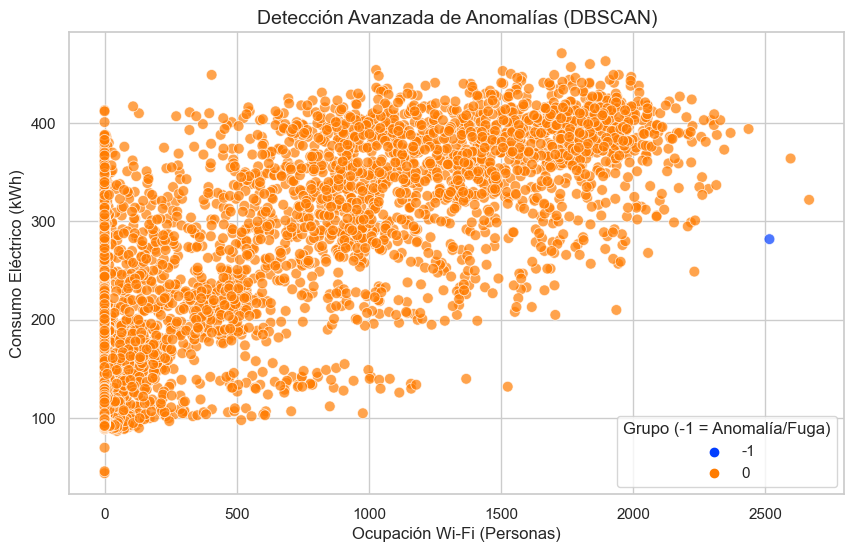

📊 DBSCAN ha encontrado 8771 horas de rutina normal.
🚨 DBSCAN ha aislado matemáticamente 1 horas como ANOMALÍAS EXTREMAS (Etiqueta -1).


In [26]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

print("🚀 Iniciando Clustering por Densidad (DBSCAN)...")

# 1. Usamos los mismos datos que ya tenías
datos_dbscan = df_ml[['Consumo_kWh', 'Ocupacion_Simulada']].copy()

# 2. Obligatorio escalar
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos_dbscan)

# 3. Aplicamos DBSCAN
# eps = Radio de búsqueda (0.3 a 0.8 suele funcionar bien tras escalar)
# min_samples = Días mínimos para considerar que un patrón es una "rutina" y no una rareza
dbscan = DBSCAN(eps=0.5, min_samples=5)
datos_dbscan['Perfil_DBSCAN'] = dbscan.fit_predict(datos_escalados)

# 4. Visualización
plt.figure(figsize=(10, 6))
# El palette 'Set1' coloreará los clusters. Las etiquetas '-1' (Anomalías) suelen salir en otro color.
sns.scatterplot(
    x='Ocupacion_Simulada', 
    y='Consumo_kWh', 
    hue='Perfil_DBSCAN', 
    palette='bright', 
    data=datos_dbscan, 
    alpha=0.7,
    s=60
)
plt.title("Detección Avanzada de Anomalías (DBSCAN)", fontsize=14)
plt.xlabel("Ocupación Wi-Fi (Personas)")
plt.ylabel("Consumo Eléctrico (kWh)")
plt.legend(title='Grupo (-1 = Anomalía/Fuga)')
plt.show()

# 5. Conteo de Anomalías
anomalias = len(datos_dbscan[datos_dbscan['Perfil_DBSCAN'] == -1])
rutinas = len(datos_dbscan[datos_dbscan['Perfil_DBSCAN'] != -1])
print(f"📊 DBSCAN ha encontrado {rutinas} horas de rutina normal.")
print(f"🚨 DBSCAN ha aislado matemáticamente {anomalias} horas como ANOMALÍAS EXTREMAS (Etiqueta -1).")

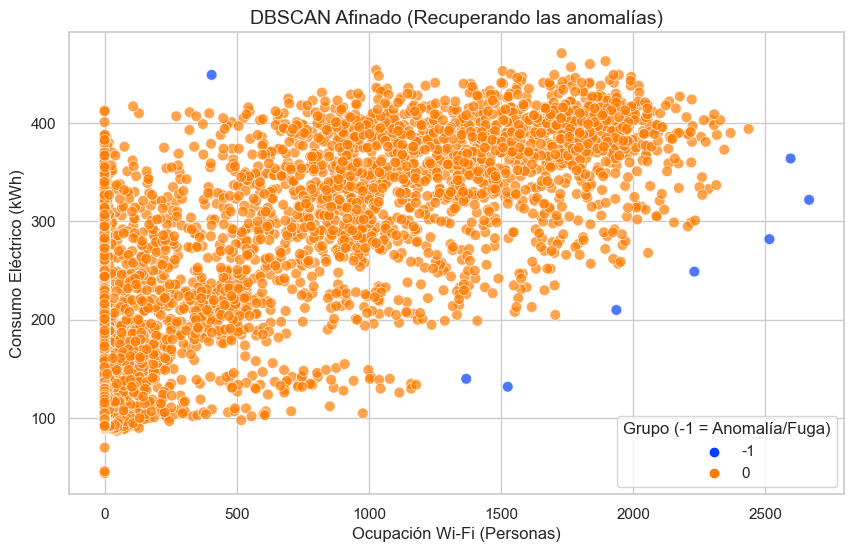

In [31]:
# Hacemos el modelo más estricto para que escupa las fugas fuera del grupo principal
# Ajusta el eps entre 0.2 y 0.4 hasta que veas que la zona superior izquierda se vuelve azul (-1)
dbscan_afinado = DBSCAN(eps=0.3, min_samples=8) 

datos_dbscan['Perfil_DBSCAN'] = dbscan_afinado.fit_predict(datos_escalados)

# Resto del código de visualización (plt.figure, sns.scatterplot...) igual que antes
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Ocupacion_Simulada', 
    y='Consumo_kWh', 
    hue='Perfil_DBSCAN', 
    palette='bright', 
    data=datos_dbscan, 
    alpha=0.7,
    s=60
)
plt.title("DBSCAN Afinado (Recuperando las anomalías)", fontsize=14)
plt.xlabel("Ocupación Wi-Fi (Personas)")
plt.ylabel("Consumo Eléctrico (kWh)")
plt.legend(title='Grupo (-1 = Anomalía/Fuga)')
plt.show()

In [27]:
import pandas as pd

print("🔍 --- BUSCANDO FALLOS DE SENSOR (Consumo = 0) --- 🔍")

# 1. Filtramos los datos donde el consumo es exactamente 0 (o menor que 5, por si hay decimales residuales)
datos_corruptos = df_ml[df_ml['Consumo_kWh'] <= 5].copy()

# 2. Contamos cuántos errores hay
print(f"Se han encontrado {len(datos_corruptos)} horas donde el sensor falló y marcó 0 kWh.\n")

# 3. Mostramos las columnas más importantes para investigar qué pasó
# (Asegúrate de poner los nombres correctos de tus columnas de fecha u hora si las tienes)

# Si tienes columnas de fecha como 'Mes' o 'Dia', añádelas a la lista de arriba.
print("Aquí tienes una muestra de los datos corruptos:")
display(datos_corruptos.head(25))

🔍 --- BUSCANDO FALLOS DE SENSOR (Consumo = 0) --- 🔍
Se han encontrado 0 horas donde el sensor falló y marcó 0 kWh.

Aquí tienes una muestra de los datos corruptos:


,Temperatura,Lluvia,Ocupacio_Percent,Ocupacion_Simulada,Consumo_kWh,Hora_del_Dia,Dia_Semana_Jueves,Dia_Semana_Lunes,Dia_Semana_Martes,Dia_Semana_Miércoles,...,Dia_Semana_Viernes,tipus_dia_Avaluacio,tipus_dia_Classe,tipus_dia_Dissabte,tipus_dia_Diumenge,tipus_dia_Festiu,tipus_dia_La Benvinguda,tipus_dia_Lectiu,tipus_dia_No lectiu,tipus_dia_Vacances


In [28]:
# Definimos los umbrales de la "Anomalía" (Ajusta estos números según tu dataset real)
umbral_wifi_vacio = 20    # Menos de 20 conexiones (básicamente guardias y servidores)
umbral_consumo_alto = 150 # Más de 150 kWh (Consumo típico de un día con actividad media)

# Filtramos las horas exactas donde ocurre esto
fugas_energia = df_ml[(df_ml['Ocupacion_Simulada'] <= umbral_wifi_vacio) & 
                      (df_ml['Consumo_kWh'] >= umbral_consumo_alto)]

# Cálculos financieros
horas_perdidas = len(fugas_energia)
kwh_desperdiciados = fugas_energia['Consumo_kWh'].sum()
precio_medio_kwh = 0.15 # Precio medio de la electricidad en España (€/kWh)
coste_euros = kwh_desperdiciados * precio_medio_kwh

print("🚨 --- REPORTE DE FUGAS ENERGÉTICAS (MIT Paper 1) --- 🚨")
print(f"Horas detectadas sin ocupación pero con alto consumo: {horas_perdidas} horas.")
print(f"Total de energía desperdiciada estimada: {kwh_desperdiciados:.2f} kWh.")
print(f"💸 Impacto económico estimado: {coste_euros:.2f} € perdidos.")

# Propuesta para el TFG:
ahorro_potencial = coste_euros * 0.60 # Asumimos que podemos recuperar un 60% automatizando apagados
print(f"✅ Integrar nuestro Gemelo Digital con los sistemas HVAC podría ahorrar ~{ahorro_potencial:.2f} € al año.")

🚨 --- REPORTE DE FUGAS ENERGÉTICAS (MIT Paper 1) --- 🚨
Horas detectadas sin ocupación pero con alto consumo: 1121 horas.
Total de energía desperdiciada estimada: 248423.00 kWh.
💸 Impacto económico estimado: 37263.45 € perdidos.
✅ Integrar nuestro Gemelo Digital con los sistemas HVAC podría ahorrar ~22358.07 € al año.


In [29]:
# 1. Aislar las horas del clúster anómalo (El Perfil 3 - Morado)
fugas = datos_cluster[datos_cluster['Perfil'] == 3].copy()

# 2. Calcular la energía desperdiciada
# Asumimos que si la ocupación es casi cero, el consumo DEBERÍA ser como el del Perfil Rojo (~150 kWh).
# Todo lo que pase de 150 kWh en esas horas moradas, es derroche puro.
consumo_base_ideal = 150
fugas['Energia_Perdida_kWh'] = fugas['Consumo_kWh'] - consumo_base_ideal

# Limpiamos posibles números negativos por seguridad
fugas['Energia_Perdida_kWh'] = fugas['Energia_Perdida_kWh'].clip(lower=0)
kwh_tirados = fugas['Energia_Perdida_kWh'].sum()

# 3. Impacto Financiero
precio_kwh = 0.15 # Precio medio en España (€/kWh)
euros_perdidos = kwh_tirados * precio_kwh

print("🚨 --- AUDITORÍA DE FUGAS ENERGÉTICAS (PERFIL 3) --- 🚨")
print(f"Horas detectadas de despilfarro (Clúster Morado): {len(fugas)} horas al año.")
print(f"⚡ Energía totalmente desperdiciada: {kwh_tirados:,.2f} kWh.")
print(f"💸 Impacto económico anual: {euros_perdidos:,.2f} € tirados a la basura.")
print("\n✅ Conclusión para el TFG: Integrar las predicciones del Wi-Fi a la climatización (HVAC) podría ahorrar gran parte de este dinero.")

🚨 --- AUDITORÍA DE FUGAS ENERGÉTICAS (PERFIL 3) --- 🚨
Horas detectadas de despilfarro (Clúster Morado): 1006 horas al año.
⚡ Energía totalmente desperdiciada: 182,816.00 kWh.
💸 Impacto económico anual: 27,422.40 € tirados a la basura.

✅ Conclusión para el TFG: Integrar las predicciones del Wi-Fi a la climatización (HVAC) podría ahorrar gran parte de este dinero.


In [30]:
import numpy as np

print("💸 --- AUDITORÍA FINANCIERA DEL SMART CAMPUS --- 💸\n")

# 1. Definimos los límites lógicos de una "Fuga Energética"
# Consideramos que el edificio está vacío si hay menos de 20 personas (ej. guardias de seguridad)
# Consideramos que hay un derroche si el consumo supera los 200 kWh en ese estado de vacío
UMBRAL_WIFI_VACIO = 20  
UMBRAL_CONSUMO_ALTO = 200 
CONSUMO_FANTASMA_JUSTIFICADO = 100 # Lo que es normal gastar (servidores, neveras, luces de emergencia)

# 2. Cazamos las discrepancias lógicas
# Filtramos el dataset maestro donde se cumplan estas condiciones anómalas
fugas_detectadas = df_ml[(df_ml['Ocupacion_Simulada'] <= UMBRAL_WIFI_VACIO) & 
                         (df_ml['Consumo_kWh'] >= UMBRAL_CONSUMO_ALTO)].copy()

# 3. Cálculos de Desperdicio
# Restamos el consumo justificado para ver cuánta energía extra se está tirando
fugas_detectadas['kWh_Derrochados'] = fugas_detectadas['Consumo_kWh'] - CONSUMO_FANTASMA_JUSTIFICADO
total_kwh_perdidos = fugas_detectadas['kWh_Derrochados'].sum()
horas_perdidas = len(fugas_detectadas)

# 4. Impacto Económico (ROI)
# Usamos un precio medio de la energía para grandes consumidores (ajustable)
PRECIO_KWH_EUROS = 0.15 
coste_total_euros = total_kwh_perdidos * PRECIO_KWH_EUROS

# Asumimos que automatizando el edificio con nuestra IA podemos evitar el 70% de estos descuidos
TASA_RECUPERACION = 0.70 
ahorro_potencial_euros = coste_total_euros * TASA_RECUPERACION

# 5. Reporte Ejecutivo
print(f"🔍 Discrepancias encontradas: {horas_perdidas} horas este año.")
print(f"   (Horas con menos de {UMBRAL_WIFI_VACIO} personas, pero consumiendo más de {UMBRAL_CONSUMO_ALTO} kWh)")
print("-" * 50)
print(f"⚡ Total de Energía Desperdiciada: {total_kwh_perdidos:,.2f} kWh")
print(f"💰 Coste Económico del Derroche:  {coste_total_euros:,.2f} €")
print("-" * 50)
print(f"✅ AHORRO POTENCIAL (ROI):        {ahorro_potencial_euros:,.2f} € / año")
print(f"   (Conectando el predictor XGBoost al sistema HVAC para forzar apagados)")

💸 --- AUDITORÍA FINANCIERA DEL SMART CAMPUS --- 💸

🔍 Discrepancias encontradas: 564 horas este año.
   (Horas con menos de 20 personas, pero consumiendo más de 200 kWh)
--------------------------------------------------
⚡ Total de Energía Desperdiciada: 98,500.00 kWh
💰 Coste Económico del Derroche:  14,775.00 €
--------------------------------------------------
✅ AHORRO POTENCIAL (ROI):        10,342.50 € / año
   (Conectando el predictor XGBoost al sistema HVAC para forzar apagados)
